In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
sns.set_theme()


from sklearn.datasets import fetch_openml


# Question 1

In [38]:
def load_data(random_state=None):
    '''
    This function fetches the MNIST dataset such that each class has 100 random samples

    ### Parameters

    `random_state` : integer for reproducible results

    ### Returns

    a tuple `(data, labels)` where 
        `data` is a `numpy.ndarray` of shape `(1000, 784)` such that each row is a flattened image sample

        `labels` is `numpy.array` of 1000 corresponding labels. 
    '''
    X, y=fetch_openml(name='mnist_784', as_frame=True, return_X_y=True)
    X=X.values
    y=y.values.astype(int)
    data, labels=None, None
    rng=np.random.default_rng(seed=random_state)
    for i in range(10):
        subset_index=y==i
        X_, y_=X[subset_index, :], y[subset_index]
        random_index=np.arange(X_.shape[0])
        rng.shuffle(random_index)
        X_sampled, y_sampled=X_[random_index[:100]], y_[random_index[:100]]
        if data is None:
            data, labels=X_sampled, y_sampled
        else:
            data=np.concatenate((data, X_sampled))
            labels=np.concatenate((labels, y_sampled))
    random_index=np.arange(data.shape[0])
    rng.shuffle(random_index)
    return data[random_index], labels[random_index]

def plot_images(data, nrows=3, ncols=3, title=''):
    '''
    This function plots the first `nrows*ncols` image samples in `data`. 

    ### Parameters

    `data` : is a `numpy.ndarray` such that each row is a flattened image sample.

    `nrows` : number of rows in the plot

    `ncols` : number of columns in the plot

    `title` : string that forms the title of each plot.
    '''
    fig, axes=plt.subplots(nrows,ncols)
    for i in range(nrows):
        for j in range(ncols):
            axes[i, j].imshow(data[i*ncols+j, :].reshape((28, 28)), cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title('%s %d'%(title, i*ncols+j+1))
    # plt.tight_layout()

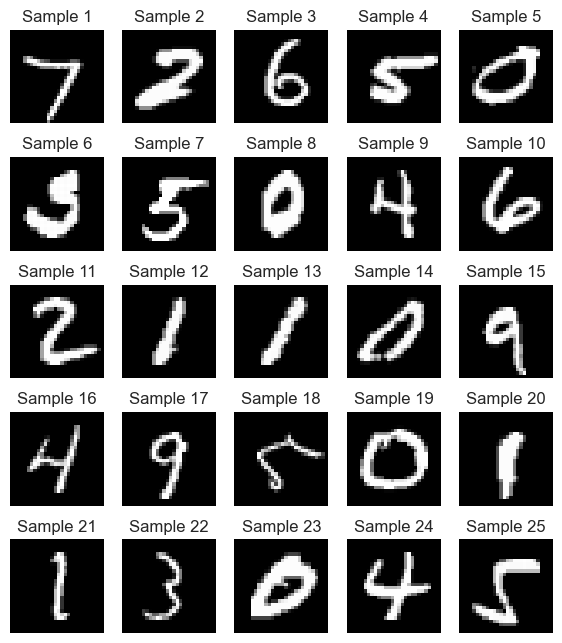

In [39]:
X, y=load_data(0)
plot_images(X, 5,5, 'Sample')
plt.gcf().set_size_inches(7, 8)

In [40]:
class PCA:
    def __init__(self):
        '''
        This class implements the PCA algorithm
        '''
        self.means=None  # a `numpy.array` each component of which is the mean of the corresponding feature
        self.evalues=None # a `numpy.array` such that each component is an eigenvalue of the covariance matrix of 
                          # the data. The eigenvalues are stored in the descending order.

        self.evectors=None # a `numpy.ndarray` such that each column is the eigenvector of the covariance matrix of
                           # the data. Each eigenvector has norm of 1. Moreover, the order of eigenvectors is the
                           # same as the order of corresponding eigenvalues stored in `evalues` variable. 

    def calc_cov_mat(self, X):
        '''
        This function returns the covariance matrix of the data passed in X. The function mean centers the data 
        before calculating the covariance matrix.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features. Covariance will be calculated
         for the columns.

        ### Returns

        the covariance matrix in the form of a `numpy.ndarray` of shape `(d, d)` where `d` is the number of 
        features(columns) in `X` 
        '''
        X_centered=X-self.means
        return (X_centered.T @ X_centered)/X.shape[0]
    
    def eigen_decompose(self, X):
        '''
        This function returns the eigenvector decomposition of the matrix `X`

        ### Parameters
        
        `X` : a square matrix in the form of a `numpy.ndarray`

        ### Returns

        a tuple `(vals, vecs)` where
            `vals` is the vector of eigenvalues of `X` in the same format as `evalues`
            `vecs` is the matrix of eigenvectors of `X` in the same format as `evectors` 
        '''
        evalues, evectors=np.linalg.eig(X)
        evalues, evectors=np.real(evalues), np.real(evectors)
        sort_index=evalues.argsort()[::-1]
        evalues, evectors=evalues[sort_index], evectors[:, sort_index]   
        return evalues, evectors     

    def fit(self, X):
        '''
        This function calculates the principal components of `X` and stores in the corresponding instance variables.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features.
        '''
        self.means=X.mean(axis=0)
        self.evalues, self.evectors=self.eigen_decompose(self.calc_cov_mat(X))
    
    def transform(self, X, use_pcs=None):
        '''
        This function reduces the dimensionality of the data passed by compressing the data into `use_pcs` number 
        of features. For doing this the first `use_pcs` components are utilized, which are stored as columns 
        of `evalues`.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features. The number of features in `X` 
         must be the same as the dimension of the eigenvectors stored in `evectors`, i.e. the number of rows in 
         `evectors`

        `use_pcs` : integer that specifies the number of principal components to use for the transformation. If 
         `use_pcs` is `None` then all principal components are used.

        ### Returns

        the transformed data matrix in a `numpy.ndarray` with the transformed data points as rows and columns as 
        features. 
        '''
        X_centered=X-self.means
        if use_pcs is None:
            use_pcs=self.evectors.shape[1]
        return X_centered @ self.evectors[:, :use_pcs]
    
    def reconstruct(self, X, use_pcs=None):
        '''
        This function reconstructs the transformed data into the original dimension using the principal components.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features. The number of features in `X` 
         must be the same as the `use_pcs`.

        `use_pcs` : integer that specifies the number of principal components to use for the transformation. If 
         `use_pcs` is `None` then all principal components are used.
        
        ### Returns

        the reconstructed data matrix in a `numpy.ndarray` with the reconstructed data points as rows and columns as
        features.
        '''

        if use_pcs is None:
            use_pcs=self.evectors.shape[1]
        return (X @ self.evectors[:, :use_pcs].T) + self.means

In [41]:
pca=PCA()
pca.fit(X)

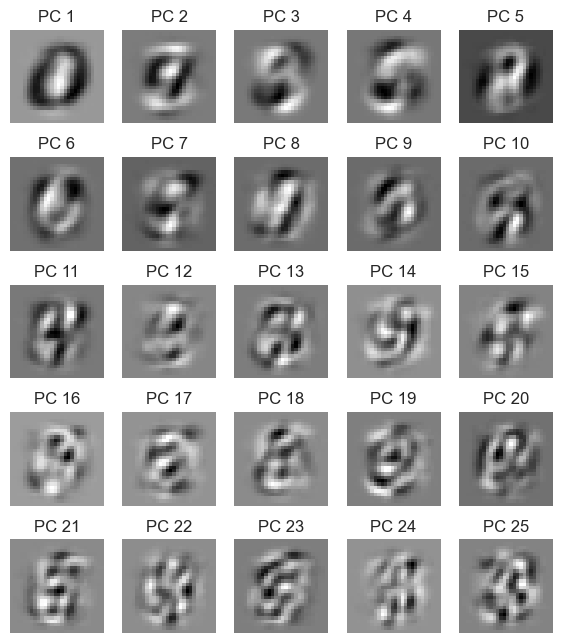

In [42]:
plot_images(pca.evectors.T, 5, 5, 'PC')
plt.gcf().set_size_inches(7, 8)

In [43]:
pca.evalues

array([ 3.43446156e+05,  2.44936687e+05,  2.21425362e+05,  1.95924557e+05,
        1.74109926e+05,  1.44303009e+05,  1.08741055e+05,  1.01997660e+05,
        9.54173013e+04,  8.48314126e+04,  7.58699561e+04,  6.74399682e+04,
        6.17744905e+04,  5.65314935e+04,  5.56732849e+04,  4.95314383e+04,
        4.71235087e+04,  4.64966631e+04,  4.14387111e+04,  3.93136883e+04,
        3.83489956e+04,  3.45407871e+04,  3.34721500e+04,  3.15898858e+04,
        3.05082923e+04,  3.00096325e+04,  2.98498960e+04,  2.77265167e+04,
        2.63048317e+04,  2.37630708e+04,  2.32565996e+04,  2.23758464e+04,
        2.07513029e+04,  1.97825443e+04,  1.86963465e+04,  1.84562007e+04,
        1.76281958e+04,  1.69965469e+04,  1.64930163e+04,  1.61179919e+04,
        1.57926311e+04,  1.49989813e+04,  1.46559189e+04,  1.43850546e+04,
        1.36277613e+04,  1.32435282e+04,  1.28111570e+04,  1.24776282e+04,
        1.16459751e+04,  1.15048544e+04,  1.05994614e+04,  1.04311529e+04,
        1.01789745e+04,  

In [44]:
def plot_for_pcs(nrows, ncols, image, for_pcs, model):
    '''
    This function plots the reconstructed image for an image using different number pricipal components.

    ### Parameters
    `nrows` : Number of rows in the plot

    `ncols` : Number of columns in the plot

    `image` : a `numpy.array` which the flattened representation of the image

    `for_pcs` : a list that specifies the number of principal components to use for that particular reconstruction
    '''
    fig, axes=plt.subplots(nrows,ncols, figsize=(6, 6))
    for i in range(nrows):
        for j in range(ncols):
            X_compressed=model.transform(image, for_pcs[i*ncols+j])
            X_recon=model.reconstruct(X_compressed, for_pcs[i*ncols+j])
            axes[i, j].imshow(X_recon.reshape((28, 28)), cmap='gray')
            axes[i, j].axis('off')
            try:
                axes[i, j].set_title('Using %d PCs'%(for_pcs[i*ncols+j]))
            except TypeError:
                axes[i, j].set_title('Using All PCs')
    # plt.tight_layout()

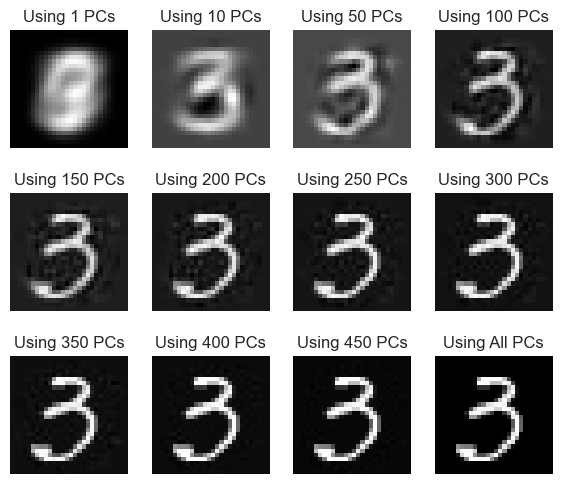

In [45]:
plot_for_pcs(3, 4, X[702], [1, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, None], pca)
plt.gcf().set_size_inches(7, 6)

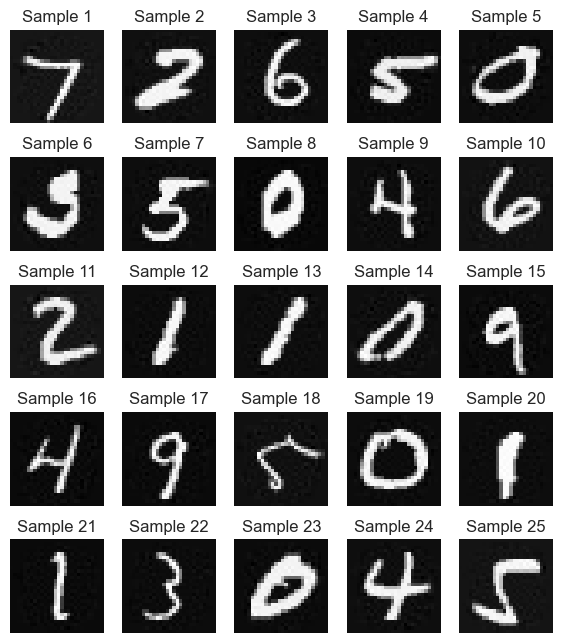

In [46]:
X_compressed=pca.transform(X, 350)
X_recon=pca.reconstruct(X_compressed, 350)
plot_images(X_recon, 5, 5, 'Sample')
plt.gcf().set_size_inches(7, 8)

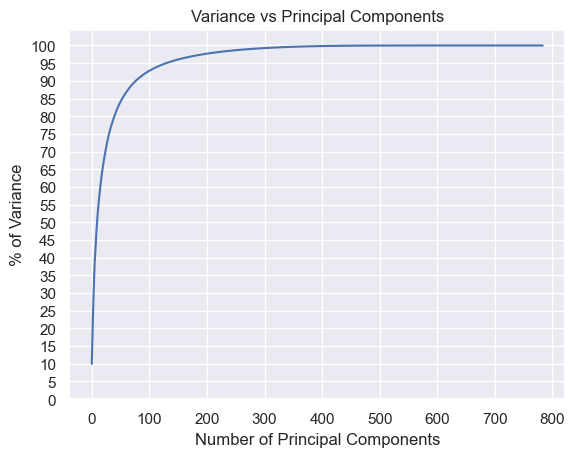

In [47]:
plt.plot((pca.evalues/pca.evalues.sum()).cumsum()*100)
ax=plt.gca()
ax.set_yticks(np.arange(105, step=5))
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('% of Variance')
ax.set_title('Variance vs Principal Components');

# Question 2

In [26]:
data=pd.read_csv('cm_dataset_2.csv', header=None)
X=data.values
X

array([[ -1.2061 ,  -2.5268 ],
       [ -3.7038 ,   0.33831],
       [  4.3444 ,   0.96302],
       ...,
       [ -2.8458 , -14.469  ],
       [-11.173  ,  -7.4088 ],
       [ -2.3857 , -13.212  ]])

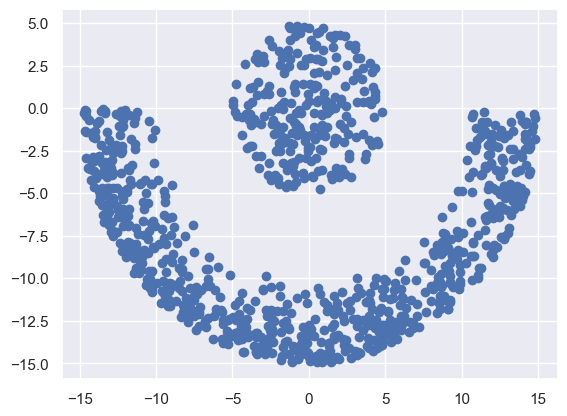

In [27]:
plt.scatter(data[0], data[1])

In [28]:
class KMeans:
    def __init__(self, n_clusters, random_state=None, max_iter=1000):
        '''
        This class implements the K-Means clustering algorithm
        '''
        self.n_clusters=n_clusters  # the number of clusters to make
        self.assignments=None # the array which specifies which training data point is assigned to which cluster.
                              # the ith element of the array is the cluster number assigned to the ith training data
                              # point   
        self.means=None  # a numpy.ndarray that specifies the means of the clusters. The array has a shape of 
                         # (n_clusters, 1, d), where d is the dimensionality of the training data.
        self.errors=[]   # array to keep track of error in each iteration.
        self.random_state=random_state # integer for reproducible initializations
        self.max_iter=max_iter  # the number of maximum iterations to run for the algorithm
    
    def initialize(self, X):
        '''
        This function picks cluster means uniformly at random from the dataset passed.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features
        '''
        rng=np.random.default_rng(self.random_state)
        self.means=X[rng.choice(X.shape[0], self.n_clusters), :].reshape((self.n_clusters, 1, -1))
        self.assignments=None
        self.errors=[]
    
    def assign_clusters(self, X):
        '''
        This function returns the cluster assignments for the data points based on the means learned.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features

        ### Returns

        a `numpy.array` which is in the same format as `assignments`
        '''
        return np.linalg.norm((X - self.means), axis=2).argmin(axis=0)
        
    def update_means(self, X):
        '''
        This function updates the means based on the cluster assignments.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features
        '''
        new_means=[]
        for cluster in range(self.n_clusters):
            new_means.append(X[self.assignments==cluster, :].mean(axis=0))
        self.means=np.array(new_means).reshape((self.n_clusters, 1, -1))

    def error(self, X):
        '''
        This function calculates the error based on the means and cluster assignments

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features

        ### Returns

        the clustering error(float)
        '''
        differences= X - self.means[self.assignments, : , :].reshape((-1, X.shape[1]))
        return np.linalg.norm(differences, axis=1).sum()

    def fit(self, X):
        '''
        This function runs the KMeans Clustering algorithm. A random initialization of means is done using the 
        `initialize` function. Then, using the `assign_clusters` and `update_means` functions, the progress is made
        iterativeliy. In each iteration, the error is also calculated using the `error` function. If the assigments
        obtained in the current iteration are same as previous assignments, then the algorithm is stopped.

        ### Paramaters 

        `X` : a `numpy.ndarray` with data points as rows and columns as features
        '''
        self.initialize(X)
        for i in range(self.max_iter):
            new_assignment=self.assign_clusters(X)
            if (self.assignments!=new_assignment).sum() == 0:
                self.errors.append(self.error(X))
                break
            else:
                self.assignments=new_assignment
                self.errors.append(self.error(X))
                self.update_means(X)
    

    def plot_clusters(self, X, clusters_colors):
        '''
        This function plots a graph with one subgraph being the error plot, and the other subgraph being a scatter 
        plot of the cluster assignments.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features

        `cluster_colors` : a list specifying the colors for different clusters.
        '''
        assignment=self.assign_clusters(X)
        fig, axes=plt.subplots(1, 2)
        axes[0].plot(self.errors)
        axes[0].set_xlabel('Iterations', fontsize='large')
        axes[0].set_ylabel('Error', fontsize='large')
        axes[0].set_title('Iteration vs Error')

        axes[1].scatter(X[:, 0], X[:, 1], cmap=colors.ListedColormap(clusters_colors), c=assignment)
        axes[1].set_xlabel('$x_1$', fontsize='large')
        axes[1].set_ylabel('$x_2$', fontsize='large')
        axes[1].set_title('Cluster Assignments', fontsize='large')
        
    def plot_voronoi(self, X, cluster_colors):
        '''
        This function plots the voronoi regions for each cluster.

        ### Parameters

        `X` : a `numpy.ndarray` with data points as rows and columns as features

        `clueter_colors` : a list specifying the colors for different clusters.
        '''
        ax=plt.axes()
        points_x=np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
        points_y=np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
        mesh=np.meshgrid(points_x, points_y)
        df=np.column_stack((mesh[0].flatten(), mesh[1].flatten()))
        
        clusters=self.assign_clusters(df)
        ax.scatter(df[:, 0], df[:, 1], s=10, marker='.', c=clusters, 
                cmap=colors.ListedColormap(cluster_colors), alpha=0.7)
        
        clusters=self.assign_clusters(X)
        ax.scatter(X[:, 0], X[:, 1], c=clusters, cmap=colors.ListedColormap(cluster_colors), edgecolors='k')
        ax.set_xlabel('$x_1$', fontsize='large')
        ax.set_ylabel('$x_2$', fontsize='large')
        ax.set_title('Cluster Assignments', fontsize='large')
        


### Part 1

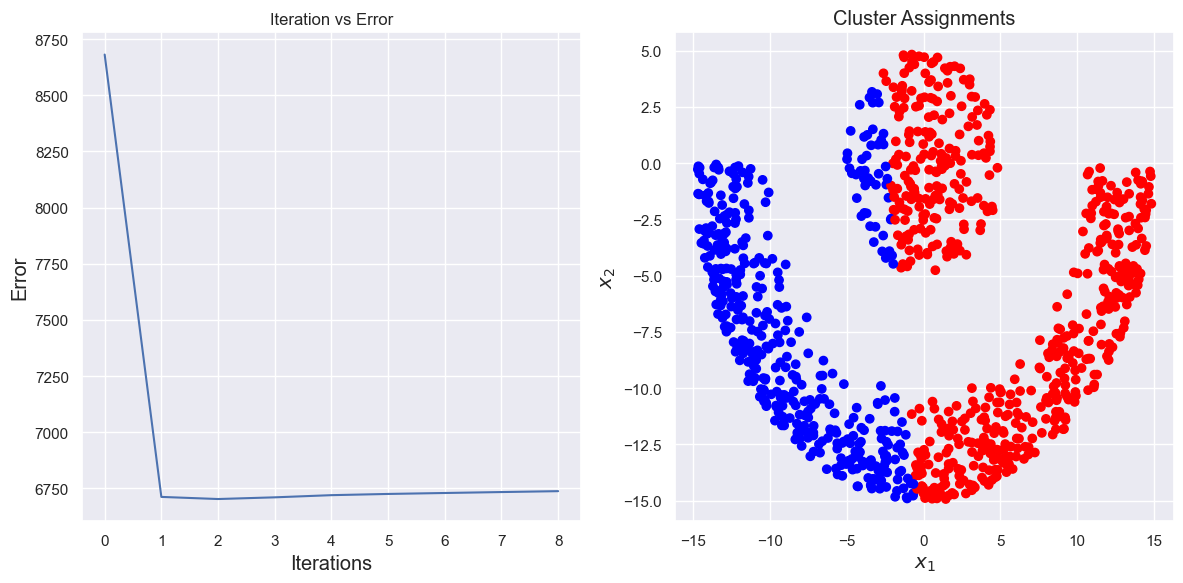

In [33]:
# 0, 100, 400, 200, 500
km=KMeans(2, 500, 1000)
km.fit(X)
km.plot_clusters(X, ['red', 'blue'])
plt.gcf().set_size_inches(12, 6)
plt.tight_layout()

### Part 2

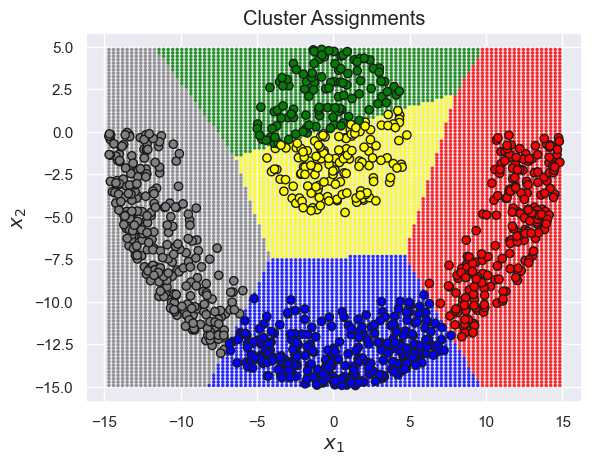

In [37]:
km=KMeans(5, 3, 1000)
km.fit(X)
km.plot_voronoi(X, ['red', 'gray', 'blue', 'yellow', 'green'])